## Import Library

In [25]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau

## Read Dataset from CSV

In [26]:
csv = pd.read_csv('/content/data_challenge.csv')

csv.info()
csv.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idHistory           500 non-null    object 
 1   vehicle_type        500 non-null    object 
 2   vehicle_name        500 non-null    object 
 3   fuel_type           500 non-null    object 
 4   machine_capacity    500 non-null    int64  
 5   daily_emission      500 non-null    int64  
 6   distance            500 non-null    int64  
 7   location            500 non-null    object 
 8   location_address    500 non-null    object 
 9   time_used           500 non-null    object 
 10  time_travel         500 non-null    int64  
 11  user_id             500 non-null    object 
 12  avg_daily_emission  500 non-null    float64
 13  avg_distance_user   500 non-null    float64
 14  motor_counts        500 non-null    int64  
 15  mobil_counts        500 non-null    int64  
 16  challeng

,idHistory,vehicle_type,vehicle_name,fuel_type,machine_capacity,daily_emission,distance,location,location_address,time_used,time_travel,user_id,avg_daily_emission,avg_distance_user,motor_counts,mobil_counts,challenge_id,chal_name
0,2be4f812-81b0-4df2-a831-614e56a15e95,mobil,Suzuki Ertiga,Pertalite,250,805512,1479,Warkop Pak Min,"Turus, Ternyang, Sumberpucung, Malang Regency,...",2023-03-21 00:00:00,120,7eaf6a97-b960-40ef-971f-ad77580d7bfa,2139303.4,23887.9,6,4,CHALLENGE027,Eco Friend Meetup
1,0acfb7fb-ada5-4a7a-9f78-72645935c820,sepeda motor,Honda Beat,Pertamax Turbo,2000,806546,36364,sabila snack,"Jalan Randupitu-Gunung Gangsir, Pagar Gunung, ...",2023-08-29 00:00:00,159,955e4fb4-95da-4e87-adee-2a7fff479979,2186638.1,19709.3,8,2,CHALLENGE015,Eco Grocer
2,f7feef39-033e-4a8b-a186-934365248ccc,mobil,Suzuki Ertiga,Diesel,150,4259071,12174,Universitas Yudharta Pasuruan,"Jl. Yudharta, Kembangkuning, Sengonagun, Pasur...",2023-06-05 00:00:00,153,913faf2b-3f75-4281-b76d-a62e69c2673c,3264225.0,24096.8,6,4,CHALLENGE027,Eco Friend Meetup
3,d10cec6b-e90d-42ca-aef6-dfd325022df8,sepeda motor,Kawasaki Ninja,Shell Super,1800,3059045,6517,Pakuwon Mall,"Jalan Mayjend. Jonosewojo, Babatan, Surabaya, ...",2023-06-29 00:00:00,176,955e4fb4-95da-4e87-adee-2a7fff479979,2186638.1,19709.3,8,2,CHALLENGE003,Green Mile
4,d82fbea0-e18e-4738-8725-c2e765496486,mobil,Toyota Avanza,Shell Super,200,3480107,20097,Jalan Semampir Tengah IIA No.17,"Medokan Semampir, Surabaya, East Java, Indonesia",2023-02-20 00:00:00,110,11c40027-0c39-42b0-9f2c-7f689a4fe902,2604622.2,28674.7,4,6,CHALLENGE004,Zero Emissions Day


## Keep relevant features

In [27]:
new_data = csv[['user_id', 'challenge_id', 'vehicle_type', 'time_used', 'daily_emission', 'avg_daily_emission', 'avg_distance_user']]

### Convert time_used into datetime format

In [28]:
new_data['time_used'] = pd.to_datetime(new_data['time_used'])
new_data.head()

<ipython-input-28-1f34a9ded8cc>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['time_used'] = pd.to_datetime(new_data['time_used'])


,user_id,challenge_id,vehicle_type,time_used,daily_emission,avg_daily_emission,avg_distance_user
0,7eaf6a97-b960-40ef-971f-ad77580d7bfa,CHALLENGE027,mobil,2023-03-21,805512,2139303.4,23887.9
1,955e4fb4-95da-4e87-adee-2a7fff479979,CHALLENGE015,sepeda motor,2023-08-29,806546,2186638.1,19709.3
2,913faf2b-3f75-4281-b76d-a62e69c2673c,CHALLENGE027,mobil,2023-06-05,4259071,3264225.0,24096.8
3,955e4fb4-95da-4e87-adee-2a7fff479979,CHALLENGE003,sepeda motor,2023-06-29,3059045,2186638.1,19709.3
4,11c40027-0c39-42b0-9f2c-7f689a4fe902,CHALLENGE004,mobil,2023-02-20,3480107,2604622.2,28674.7


### Sorting the data based on user_id and time_used in ascending order

In [29]:
new_data = new_data.sort_values(by=['user_id', 'time_used'])

In [30]:
new_data.head()

,user_id,challenge_id,vehicle_type,time_used,daily_emission,avg_daily_emission,avg_distance_user
316,015fc899-ae7a-4301-9e54-29634bcef4c3,CHALLENGE010,sepeda motor,2023-02-16,1155980,2292038.9,26690.2
282,015fc899-ae7a-4301-9e54-29634bcef4c3,CHALLENGE011,sepeda motor,2023-02-26,674931,2292038.9,26690.2
202,015fc899-ae7a-4301-9e54-29634bcef4c3,CHALLENGE003,sepeda motor,2023-04-27,384110,2292038.9,26690.2
324,015fc899-ae7a-4301-9e54-29634bcef4c3,CHALLENGE029,sepeda motor,2023-04-30,4339994,2292038.9,26690.2
289,015fc899-ae7a-4301-9e54-29634bcef4c3,CHALLENGE005,mobil,2023-06-12,380011,2292038.9,26690.2


###Encoded Categorical Variables

In [31]:
user_encoder = LabelEncoder()
new_data['user_id_encoded'] = user_encoder.fit_transform(new_data['user_id'])

challenge_encoder = LabelEncoder()
new_data['challenge_id_encoded'] = challenge_encoder.fit_transform(new_data['challenge_id'])

vehicle_encoder = LabelEncoder()
new_data['vehicle_type_encoded'] = vehicle_encoder.fit_transform(new_data['vehicle_type'])

Select only relevant value and drop the original categorical columns, replace it with encoded one.

In [32]:
data_processed = new_data[['user_id_encoded', 'challenge_id_encoded', 'vehicle_type_encoded', 'time_used', 'daily_emission', 'avg_daily_emission', 'avg_distance_user']]
data_processed.head()

,user_id_encoded,challenge_id_encoded,vehicle_type_encoded,time_used,daily_emission,avg_daily_emission,avg_distance_user
316,0,8,1,2023-02-16,1155980,2292038.9,26690.2
282,0,9,1,2023-02-26,674931,2292038.9,26690.2
202,0,2,1,2023-04-27,384110,2292038.9,26690.2
324,0,20,1,2023-04-30,4339994,2292038.9,26690.2
289,0,4,0,2023-06-12,380011,2292038.9,26690.2


### Shuffle data

In [33]:
new_data = new_data.sample(frac=1, random_state=42)

### Create interaction matrix

Create interaction matrix based on whether the user got and completed the challenges or not.

In [34]:
interaction_matrix = data_processed.pivot_table(index='user_id_encoded', columns='challenge_id_encoded', aggfunc='size', fill_value=0)

# Display the interaction matrix
interaction_matrix.head()

challenge_id_encoded,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
user_id_encoded,,,,,,,,,,,,,,,,,,,,,
0,0,1,1,0,1,0,0,0,1,1,...,0,0,1,0,0,1,1,1,0,1
1,0,1,0,0,0,1,0,0,1,0,...,0,0,1,0,1,1,1,0,1,1
2,1,0,0,0,1,1,0,1,0,1,...,1,0,0,0,1,1,0,1,0,1
3,0,0,0,1,1,1,0,1,0,1,...,1,1,1,0,0,1,0,0,0,1
4,0,1,0,1,0,1,0,1,0,1,...,0,0,0,0,1,1,0,0,1,1


### Create sequence

In [35]:
def create_sequences(df, sequence_length=10):
    sequences = []
    labels = []

    for user_id in df['user_id_encoded'].unique():
        user_data = df[df['user_id_encoded'] == user_id].sort_values(by='time_used')

        if len(user_data) >= sequence_length:
            challenges = user_data['challenge_id_encoded'].values

            for i in range(len(challenges) - sequence_length + 1):
                sequences.append(challenges[i:i+sequence_length-1])
                labels.append(challenges[i+sequence_length-1])

    return np.array(sequences), np.array(labels)

### Split dataset into training and validation set

Ensure that the splitting is fully based on the complete user activities, so that a single user's data is not divided into separate sets.

In [36]:
user_ids = new_data['user_id_encoded'].unique()
train_user_ids, val_user_ids = train_test_split(user_ids, test_size=0.25, random_state=42)

In [37]:
train_data = new_data[new_data['user_id_encoded'].isin(train_user_ids)]
val_data = new_data[new_data['user_id_encoded'].isin(val_user_ids)]

In [38]:
train_sequences, train_labels = create_sequences(train_data)
val_sequences, val_labels = create_sequences(val_data)

In [39]:
user_interaction_counts = new_data.groupby('user_id_encoded').size()

train_interaction_counts = train_data.groupby('user_id_encoded').size()
val_interaction_counts = val_data.groupby('user_id_encoded').size()

print(f"Total interactions for all users:\n{user_interaction_counts.head()}")
print(f"Total interactions for users in the training set:\n{train_interaction_counts.head()}")
print(f"Total interactions for users in the validation set:\n{val_interaction_counts.head()}")

Total interactions for all users:
user_id_encoded
0    10
1    10
2    10
3    10
4    10
dtype: int64
Total interactions for users in the training set:
user_id_encoded
0    10
1    10
2    10
3    10
5    10
dtype: int64
Total interactions for users in the validation set:
user_id_encoded
4     10
8     10
9     10
10    10
13    10
dtype: int64


In [40]:
print(f"Train sequences shape: {train_sequences.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train sequences shape: (37, 9)
Train labels shape: (37,)


In [41]:
print(f"Train sequences shape: {train_sequences.shape}")
print(f"Train labels shape: {val_sequences.shape}")

Train sequences shape: (37, 9)
Train labels shape: (13, 9)


To check the distribution for challenge in both sets

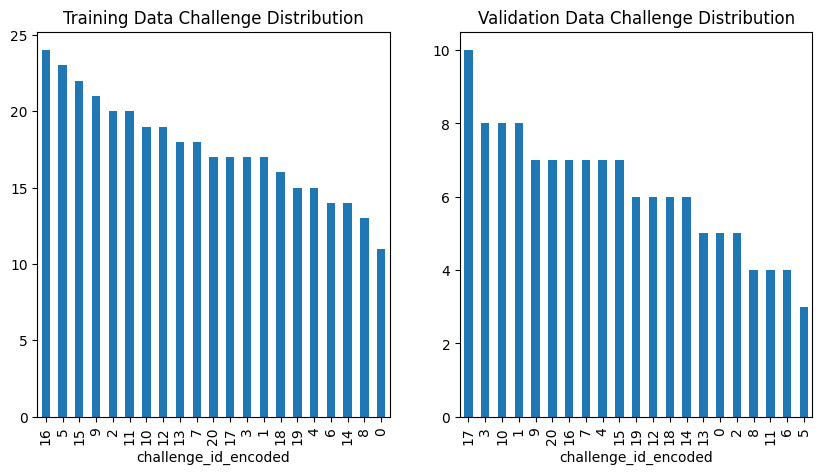

In [42]:
train_challenge_counts = train_data['challenge_id_encoded'].value_counts()
val_challenge_counts = val_data['challenge_id_encoded'].value_counts()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
train_challenge_counts.plot(kind='bar', title='Training Data Challenge Distribution')
plt.subplot(1, 2, 2)
val_challenge_counts.plot(kind='bar', title='Validation Data Challenge Distribution')
plt.show()


## Model

In [43]:
embedding_dim = 50
rnn_units = 64
num_users = len(user_encoder.classes_)
num_challenges = len(challenge_encoder.classes_)
max_sequence_length = 9

In [44]:
user_input = Input(shape=(max_sequence_length,), name='user_input')
challenge_input = Input(shape=(max_sequence_length,), name='challenge_input')

user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim, input_length=max_sequence_length)(user_input)

challenge_embedding = Embedding(input_dim=num_challenges, output_dim=embedding_dim, input_length=max_sequence_length)(challenge_input)

merged = Concatenate()([user_embedding, challenge_embedding])

lstm_output = Bidirectional(LSTM(rnn_units,
                                  return_sequences=False,
                                  kernel_regularizer=regularizers.l2(0.01)))(merged)

lstm_output = Dropout(0.3)(lstm_output)

output = Dense(num_challenges, activation='softmax')(lstm_output)

model = Model(inputs=[user_input, challenge_input], outputs=output)

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 9)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ challenge_input           │ (None, 9)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_2 (Embedding)   │ (None, 9, 50)          │          2,500 │ user_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_3 (Embedding)   │ (None, 9, 50)          │          1,050 │ challenge_input[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 9, 100)         │              0 │ embedding_2[0][0],     │
│ (Concatenate)             │                        │                │ embedding_3[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 128)            │         84,480 │ concatenate_1[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ bidirectional_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 21)             │          2,709 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 90,739 (354.45 KB)

 Trainable params: 90,739 (354.45 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    [train_sequences, train_sequences],
    train_labels,
    epochs=100,
    batch_size=32,
    validation_data=([val_sequences, val_sequences], val_labels),
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 582ms/step - accuracy: 0.0465 - loss: 5.9337 - val_accuracy: 0.1538 - val_loss: 5.8033
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1422 - loss: 5.7946 - val_accuracy: 0.0769 - val_loss: 5.6743
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1213 - loss: 5.6651 - val_accuracy: 0.0769 - val_loss: 5.5501
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1706 - loss: 5.5368 - val_accuracy: 0.0769 - val_loss: 5.4299
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1318 - loss: 5.4117 - val_accuracy: 0.0769 - val_loss: 5.3135
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1033 - loss: 5.2940 - val_accuracy: 0.0769 - val_loss: 5.2008
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1422 - loss: 5.1775 - val_accuracy: 0.0769 - val_loss: 5.0917
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1137 - loss: 5.0671 - val_accuracy: 0.0769 - val_loss